In [2]:
with open("book.txt", "r", encoding="utf-8") as f:
    file_data = f.read()
print(len(file_data))
print(file_data[:99])

5301825
The Project Gutenberg eBook of Frankenstein; or, the modern prometheus
    
This eBook is for the u


In [3]:
import re

new_data = re.split(r'([,.:;?_!"()\']|--|\s)', file_data)
# print(new_data[:99])

result = [item for item in new_data if item.strip()]
print(result[:99])

['The', 'Project', 'Gutenberg', 'eBook', 'of', 'Frankenstein', ';', 'or', ',', 'the', 'modern', 'prometheus', 'This', 'eBook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'United', 'States', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', '.', 'You', 'may', 'copy', 'it', ',', 'give', 'it', 'away', 'or', 're-use', 'it', 'under', 'the', 'terms', 'of', 'the', 'Project', 'Gutenberg', 'License', 'included', 'with', 'this', 'eBook', 'or', 'online', 'at', 'www', '.', 'gutenberg', '.', 'org', '.', 'If', 'you', 'are', 'not', 'located', 'in', 'the', 'United', 'States', ',', 'you', 'will', 'have', 'to', 'check', 'the', 'laws', 'of', 'the', 'country', 'where', 'you', 'are', 'located', 'before']


In [4]:
preprocessed = result
print(len(preprocessed))
print(preprocessed[:10])

565695
['The', 'Project', 'Gutenberg', 'eBook', 'of', 'Frankenstein', ';', 'or', ',', 'the']


In [5]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

463992


In [6]:
vocab = {token: integer for integer, token in enumerate(all_words)}

In [7]:
for i, item in enumerate(vocab.items()):
    print(item)
    if i>10:
        break

('!', 0)
('#516', 1)
('#84]', 2)
('$1', 3)
('$5', 4)
('&c', 5)
("'", 6)
('(', 7)
(')', 8)
('***', 9)
('+1', 10)
(',', 11)


In [8]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        import re
        preprocessed = re.split(r'([,.:;?_!\"()[\\\]])|--|\s', text)
        preprocessed = [item.strip() for item in preprocessed if item and item.strip()]
        ids = [self.str_to_int[item] for item in preprocessed]
        return ids

    def decode(self, ids):
        import re
        text = " ".join([self.int_to_str[i] for i in ids])
        # Corrected \s instead of |s
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text



In [9]:
tokenizer = SimpleTokenizerV1(vocab)
text = """ She was the best woman I had ever had a date with"""
ids = tokenizer.encode(text)
print(ids)

[65853, 452407, 407874, 109900, 458843, 34404, 211334, 183555, 211334, 78953, 154662, 458426]


In [10]:
tokenizer.decode(ids)

'She was the best woman I had ever had a date with'

In [11]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>","<|unk|>"])
vocab = {token: integer for integer, token in enumerate(all_tokens)}
len(vocab.items())


463994

In [12]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('”', 463989)
('”]', 463990)
('•', 463991)
('<|endoftext|>', 463992)
('<|unk|>', 463993)


In [13]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        import re
        preprocessed = re.split(r'([,.:;?_!\"()[\\\]])|--|\s', text)
        preprocessed = [item.strip() for item in preprocessed if item and item.strip()]
        preprocessed = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        import re
        text = " ".join([self.int_to_str[i] for i in ids])
        # Corrected \s instead of |s
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [14]:
tokenizer = SimpleTokenizerV2(vocab)
text1 = "Hi, do you like tea?"
text2 = "Nishita is going to be my wife soon!"

text = " <|endoftext|> ".join((text1,text2))
print(text)

Hi, do you like tea? <|endoftext|> Nishita is going to be my wife soon!


In [15]:
ids = tokenizer.encode(text)
print(ids)

[463993, 11, 167938, 462374, 251059, 404489, 130, 463992, 463993, 238364, 206288, 412469, 106786, 274090, 457113, 381421, 0]


In [16]:
tokenizer.decode(ids)

'<|unk|>, do you like tea? <|endoftext|> <|unk|> is going to be my wife soon!'

In [17]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [18]:
tokenizer = tiktoken.get_encoding("o200k_base")

In [19]:
text = (
    "Hey, do you like barley tea? <|endoftext|> Science has found out that it has a lot of benefits"
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[25216, 11, 621, 481, 1299, 135069, 17966, 30, 220, 199999, 13993, 853, 2491, 842, 484, 480, 853, 261, 3261, 328, 8808]


In [20]:
string = tokenizer.decode(integers)
print(string)


Hey, do you like barley tea? <|endoftext|> Science has found out that it has a lot of benefits


In [21]:
import torch

input_ids = torch.tensor([2,3,5,1])
vocab_size = 6
output_dim = 3 
torch.manual_seed(123)

embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)


Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [22]:
print(embedding_layer(torch.tensor([3])))
print(embedding_layer(input_ids))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)
tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [23]:
position_ids = torch.arange(4)

position_embedding_layer = torch.nn.Embedding(4, 3)

position_embeddings = position_embedding_layer(position_ids)

token_embeddings = embedding_layer(input_ids)

final_embeddings = token_embeddings + position_embeddings

print(final_embeddings)

tensor([[ 0.6446,  1.0331,  0.1521],
        [ 0.2957, -0.0285, -2.2958],
        [-3.7578,  0.1197, -3.5071],
        [ 2.0735,  0.3653,  1.4306]], grad_fn=<AddBackward0>)


In [24]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [25]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


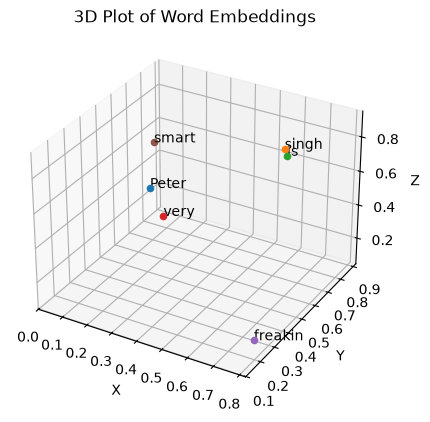

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

words = ['Peter', 'singh', 'is', 'very', 'freakin', 'smart']

x_coords = inputs[:,0].numpy() 
y_coords = inputs[:,1].numpy() 
z_coords = inputs[:,2].numpy() 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for x,y,z, word in zip(x_coords, y_coords, z_coords, words):
    ax.scatter(x,y,z)
    ax.text(x,y,z,word,fontsize=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title('3D Plot of Word Embeddings')
plt.show()


In [27]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [28]:
attn_scores_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention Weights:",attn_scores_2_tmp)
print("Sum:",attn_scores_2_tmp.sum())

Attention Weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In [29]:
def softmax_naive(x):
    return torch.exp(x)/torch.exp(x).sum(dim=0)
attn_weights_2_naive = softmax_naive(attn_scores_2)
print("Attention weights:",attn_weights_2_naive)
print("Sum:",attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [30]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:",attn_weights_2)
print("Sum:",attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


In [31]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])
